In [1]:
!pip install -Uq numpy

In [2]:
!pip install -Uq matplotlib

In [3]:
!pip install -Uq pymcel

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import pymcel as pc

Bienvenido a PyMCel v0.9.18 ¡al infinito y más allá!


In [5]:
# Definición del sistema: Sol fijo, Tierra y Apophis
sistema = [
    dict(m=1.0, r=np.array([0.0, 0.0, 0.0]), v=np.array([0.0, 0.0, 0.0])), # Sol
    dict(m=3e-6, r=np.array([1.0, 0.0, 0.0]), v=np.array([0.0, 1.0, 0.0])), # Tierra
    dict(m=1e-10, r=np.array([0.8, 0.0, 0.0]), v=np.array([0.0, 1.2, 0.0])), # Apophis
]

In [6]:
def aceleraciones(sistema):
    n = len(sistema)
    a = [np.zeros(3) for _ in range(n)]
    
    for i in range(n):
        if i == 0:  # Sol fijo, no recibe aceleraciones
            continue
        for j in range(n):
            if i != j:
                r_vec = sistema[j]['r'] - sistema[i]['r']
                eps = 1e-5
                dist = np.linalg.norm(r_vec) + 1e-10
                a[i] += sistema[j]['m'] * r_vec / (dist**2 + eps**2)**(3/2)
    return a

In [7]:
def paso_leapfrog(sistema, dt):
    a = aceleraciones(sistema)
    for i in range(1, len(sistema)): 
        sistema[i]['v'] += 0.5 * a[i] * dt

    for i in range(1, len(sistema)):  # No mover Sol
        sistema[i]['r'] += sistema[i]['v'] * dt

    a_new = aceleraciones(sistema)
    for i in range(1, len(sistema)):  
        sistema[i]['v'] += 0.5 * a_new[i] * dt

# Parámetros de simulación
dt = 0.001
pasos = 20000

trayectorias = [[] for _ in sistema]

for _ in range(pasos):
    paso_leapfrog(sistema, dt)
    for i in range(len(sistema)):
        trayectorias[i].append(sistema[i]['r'].copy())


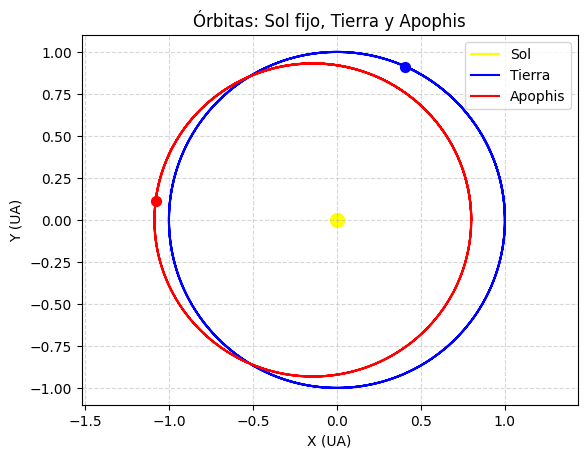

In [8]:
colors = ['yellow', 'blue', 'red']
labels = ['Sol', 'Tierra', 'Apophis']

for i in range(len(sistema)):
    tray = np.array(trayectorias[i])
    plt.plot(tray[:,0], tray[:,1], color=colors[i], label=labels[i])
    plt.scatter(tray[-1,0], tray[-1,1], color=colors[i], s=50)  

plt.scatter(0, 0, color='yellow', s=100)  # Sol destacado en el origen
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.axis('equal')
plt.xlabel('X (UA)')
plt.ylabel('Y (UA)')
plt.title('Órbitas: Sol fijo, Tierra y Apophis')
plt.show()


Añado mas planetas gradualmente y comienzo por marte y venus


In [9]:
sistema = [
    dict(m=1.0, r=np.array([0.0, 0.0, 0.0]), v=np.array([0.0, 0.0, 0.0])), # Sol
    dict(m=3e-6, r=np.array([1.0, 0.0, 0.0]), v=np.array([0.0, 1.0, 0.0])), # Tierra
    dict(m=1e-10, r=np.array([0.8, 0.0, 0.0]), v=np.array([0.0, 1.2, 0.0])), # Apophis
    dict(m=3.2e-7,r=np.array([1.52, 0.0, 0.0]), v=np.array([0.0, 0.81, 0.0])), # Marte
    dict(m=2.4e-6,r=np.array([0.72, 0.0, 0.0]),v=np.array([0.0, 1.18, 0.0])), #Venus
    dict(m=1.7e-7,r=np.array([0.39, 0.0, 0.0]),v=np.array([0.0, 1.6, 0.0])) #Mercurio
]

In [10]:
def aceleraciones(sistema):
    n = len(sistema)
    a = [np.zeros(3) for _ in range(n)]
    
    for i in range(n):
        if i == 0:  # Sol fijo, no recibe aceleraciones
            continue
        for j in range(n):
            if i != j:
                r_vec = sistema[j]['r'] - sistema[i]['r']
                eps = 1e-5
                dist = np.linalg.norm(r_vec) + 1e-10
                a[i] += sistema[j]['m'] * r_vec / (dist**2 + eps**2)**(3/2)
    return a

In [11]:
def paso_leapfrog(sistema, dt):
    a = aceleraciones(sistema)
    for i in range(1, len(sistema)): 
        sistema[i]['v'] += 0.5 * a[i] * dt

    for i in range(1, len(sistema)):  # No mover Sol
        sistema[i]['r'] += sistema[i]['v'] * dt

    a_new = aceleraciones(sistema)
    for i in range(1, len(sistema)):  
        sistema[i]['v'] += 0.5 * a_new[i] * dt

# Parámetros de simulación
dt = 0.0002
pasos = 70000

trayectorias = [[] for _ in sistema]

for _ in range(pasos):
    paso_leapfrog(sistema, dt)
    for i in range(len(sistema)):
        trayectorias[i].append(sistema[i]['r'].copy())

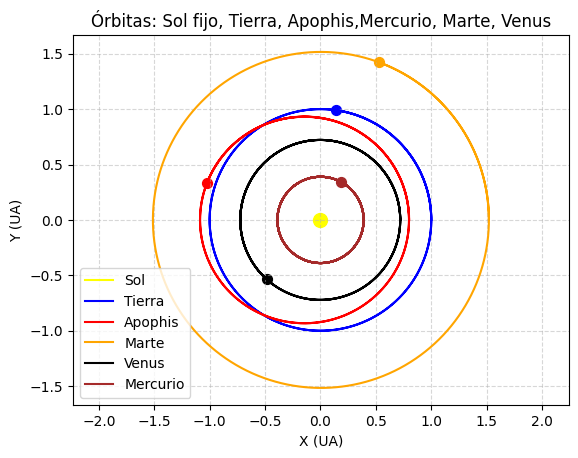

In [13]:
colors = ['yellow', 'blue', 'red', 'orange', 'black','brown']
labels = ['Sol', 'Tierra', 'Apophis', 'Marte', 'Venus', 'Mercurio']

for i in range(len(sistema)):
    tray = np.array(trayectorias[i])
    plt.plot(tray[:,0], tray[:,1], color=colors[i], label=labels[i])
    plt.scatter(tray[-1,0], tray[-1,1], color=colors[i], s=50)  

plt.scatter(0, 0, color='yellow', s=100)  # Sol destacado en el origen
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.axis('equal')
plt.xlabel('X (UA)')
plt.ylabel('Y (UA)')
plt.title('Órbitas: Sol fijo, Tierra, Apophis,Mercurio, Marte, Venus')
plt.show()


C:\Users\DEIBE\AppData\Local\Temp\ipykernel_12148\2890967528.py:66: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()


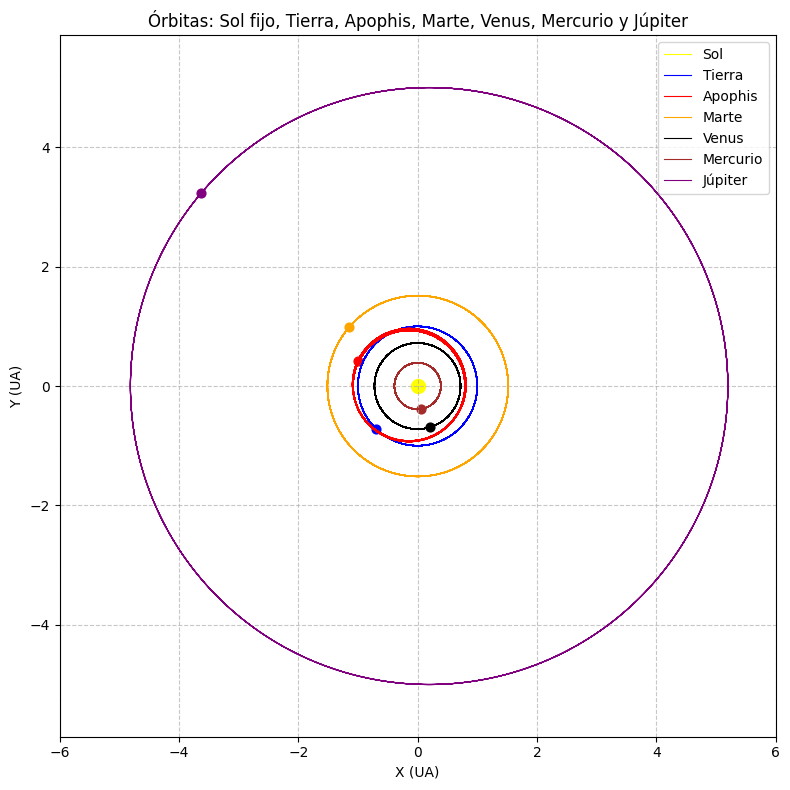

In [14]:
# Sistema con Sol, Tierra, Apophis, Marte, Venus, Mercurio y Júpiter
sistema = [
    dict(m=1.0, r=np.array([0.0, 0.0, 0.0]), v=np.array([0.0, 0.0, 0.0])), # Sol
    dict(m=3e-6, r=np.array([1.0, 0.0, 0.0]), v=np.array([0.0, 1.0, 0.0])), # Tierra
    dict(m=1e-10, r=np.array([0.8, 0.0, 0.0]), v=np.array([0.0, 1.2, 0.0])), # Apophis
    dict(m=3.2e-7, r=np.array([1.52, 0.0, 0.0]), v=np.array([0.0, 0.81, 0.0])), # Marte
    dict(m=2.4e-6, r=np.array([0.72, 0.0, 0.0]), v=np.array([0.0, 1.18, 0.0])), # Venus
    dict(m=1.7e-7, r=np.array([0.39, 0.0, 0.0]), v=np.array([0.0, 1.6, 0.0])), # Mercurio
    dict(m=9.5e-4, r=np.array([5.2, 0.0, 0.0]), v=np.array([0.0, 0.43, 0.0]))  # Júpiter
]

def aceleraciones(sistema):
    n = len(sistema)
    a = [np.zeros(3) for _ in range(n)]
    for i in range(n):
        if i == 0:  # Sol fijo
            continue
        for j in range(n):
            if i != j:
                r_vec = sistema[j]['r'] - sistema[i]['r']
                eps = 1e-5
                dist = np.linalg.norm(r_vec) + 1e-10
                a[i] += sistema[j]['m'] * r_vec / (dist**2 + eps**2)**(3/2)
    return a

def paso_leapfrog(sistema, dt):
    a = aceleraciones(sistema)
    for i in range(1, len(sistema)):
        sistema[i]['v'] += 0.5 * a[i] * dt
    for i in range(1, len(sistema)):
        sistema[i]['r'] += sistema[i]['v'] * dt
    a_new = aceleraciones(sistema)
    for i in range(1, len(sistema)):
        sistema[i]['v'] += 0.5 * a_new[i] * dt

# Parámetros de simulación
dt = 0.0005
pasos = 900000   # suficiente para que Júpiter complete su órbita (~12 años)

trayectorias = [[] for _ in sistema]

for _ in range(pasos):
    paso_leapfrog(sistema, dt)
    for i in range(len(sistema)):
        trayectorias[i].append(sistema[i]['r'].copy())

colors = ['yellow', 'blue', 'red', 'orange', 'black', 'brown', 'purple']
labels = ['Sol', 'Tierra', 'Apophis', 'Marte', 'Venus', 'Mercurio', 'Júpiter']

# Gráfica
plt.figure(figsize=(8,8))
for i in range(len(sistema)):
    tray = np.array(trayectorias[i])
    plt.plot(tray[:,0], tray[:,1], color=colors[i], label=labels[i], linewidth=0.8)
    plt.scatter(tray[-1,0], tray[-1,1], color=colors[i], s=40)

plt.scatter(0, 0, color='yellow', s=100)  # Sol en el origen
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.axis('equal')
plt.xlabel('X (UA)')
plt.ylabel('Y (UA)')
plt.title('Órbitas: Sol fijo, Tierra, Apophis, Marte, Venus, Mercurio y Júpiter')
plt.xticks(np.arange(-6, 7, 2))
plt.yticks(np.arange(-6, 7, 2))
plt.tight_layout()
plt.show()
